In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from KCircles import KCircles

# Génerer les données

In [16]:
size = 150
r = 0.7
gap = 1.2
C = np.array([[0, 0], [2, 0], [4, 0], [1, -gap], [3, -gap]])
X = []
for c in C:
    data = make_circles(2*size, noise=0.1)
    X_ = data[0][data[1]==0] + c
    X.append(X_)
X = np.concatenate(X)

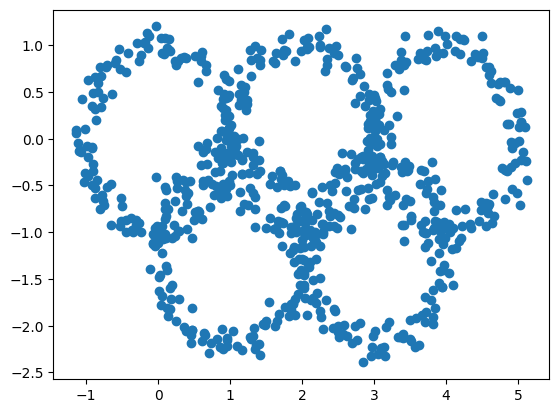

In [17]:
plt.scatter(X[:, 0], X[:, 1])

# Entrainement

In [33]:
model = KCircles(5)
model.histo_track('centers', 'loss')
model.multi_fit(X, 300, 100)
model.fit(X, iter=1000, init=False)

9.599656242862034
22.47962799174981
20.437290478453527
20.55358683986906
18.32028981083224
32.05832594976593
19.169913932943736
16.547019848079238
12.140721744970413
18.92982023788577
22.528627634856136
23.97320805671893
18.805897527870876
22.87024068640804
22.168392145211335
18.60421194118874
15.939808840323852
18.179233216785647
18.686769361042217
17.88882836685123
18.754085477971508
18.127696984455135
17.703038955807195
21.922270873823436
13.439111835231833
19.803967417536395
23.37325790541061
20.628209864492533
16.666042275363058
25.90105018694261
18.758311707048108
24.27700119223253
16.540045975483622
21.637381801066446
17.587992774819107
22.121991458869168
22.09774838972466
17.63143512019346
18.668653134495024
21.516799804300213
18.807518138637413
15.125414842569663
14.829921816731012
20.638909833828322
14.467152406891088
20.712735878657426
21.010327385985953
22.372966250891096
16.32120974941899
16.548733396443897
25.34236978140165
18.5784596421895
16.913624718542415
16.667101248

In [34]:
C = model.centers.copy()
histo = model.histo['centers']
y, loss = model.predict(X, loss=True)
loss

5.94517551321897

# Résultats

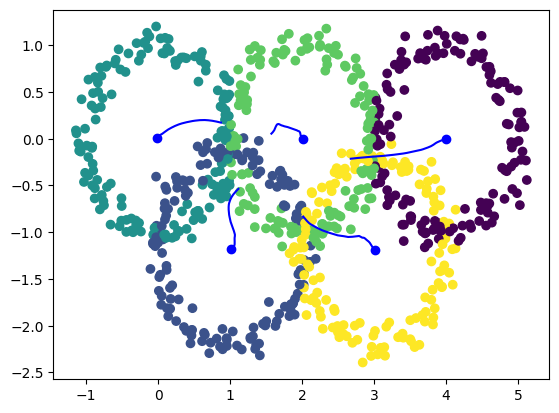

In [35]:
X_histo, Y_histo = np.array(histo).T
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(C[:, 0], C[:, 1], c='blue')
for j in range(len(X_histo)):
    plt.plot(X_histo[j], Y_histo[j], c='blue')

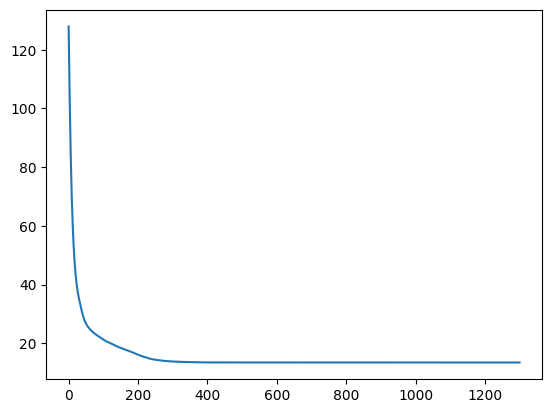

In [21]:
plt.plot(model.histo['loss'])

In [36]:
_, loss = model.predict(X, loss=True)
loss

5.94517551321897

In [37]:
err = []
for j in range(5):
    y_ = y[j*150:(j+1)*150]
    err.append((y_ != np.bincount(y_).argmax()))
err = np.concatenate(err)
nb_err = err.sum()
print(f'Il y a {nb_err} erreurs, soit {nb_err/len(y):.2%}')

Il y a 110 erreurs, soit 14.67%


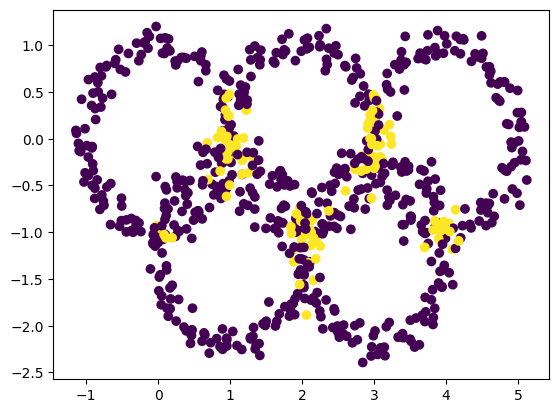

In [38]:
plt.scatter(X[:, 0], X[:, 1], c=err)